In [40]:
import pandas as pd
df = pd.read_csv('master.csv')
df

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers
...,...,...,...,...,...,...,...,...,...,...,...,...
27815,Uzbekistan,2014,female,35-54 years,107,3620833,2.96,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation X
27816,Uzbekistan,2014,female,75+ years,9,348465,2.58,Uzbekistan2014,0.675,"63,067,077,179",2309,Silent
27817,Uzbekistan,2014,male,5-14 years,60,2762158,2.17,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z
27818,Uzbekistan,2014,female,5-14 years,44,2631600,1.67,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z


In [41]:
df.isna().sum()

country                   0
year                      0
sex                       0
age                       0
suicides_no               0
population                0
suicides/100k pop         0
country-year              0
HDI for year          19456
 gdp_for_year ($)         0
gdp_per_capita ($)        0
generation                0
dtype: int64

Text(0.5, 1.0, 'Quantifying missing data')

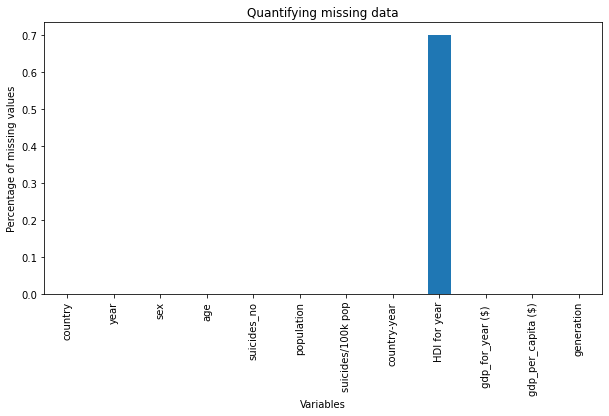

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 


df.isnull().mean().plot.bar(figsize=(10,5))
plt.ylabel('Percentage of missing values')
plt.xlabel('Variables')
plt.title('Quantifying missing data')

In [43]:
df.isna().
         sum().
         reset_index(name="n").
         plot.bar(x='index', y='n', rot=45)

SyntaxError: invalid syntax (2962227113.py, line 1)

In [44]:
df['country'].nunique()

101

In [45]:
df['age'].nunique()

6

In [46]:
df.head()

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
df_summary = df.groupby('year').sum()
df_summary

,suicides_no,population,suicides/100k pop,HDI for year,gdp_per_capita ($)
year,,,,,
1985,116063,1008600086,6811.89,310.428,3508548
1986,120670,1029909613,6579.84,0.000,4104636
1987,126842,1095029726,7545.45,0.000,5645760
1988,121026,1054094424,7473.13,0.000,5870508
1989,160244,1225514347,8036.54,0.000,6068424
1990,193361,1466620100,9878.75,429.480,7531260
1991,198020,1489988384,10321.06,0.000,7782096
1992,211473,1569539447,10528.88,0.000,8195232
1993,221565,1530416654,10790.29,0.000,8231796


In [49]:
df_summary['suicides_per_100k'] = (df_summary['suicides_no'] / df_summary['population']) * 100000

In [50]:
df_summary

,suicides_no,population,suicides/100k pop,HDI for year,gdp_per_capita ($),suicides_per_100k
year,,,,,,
1985,116063,1008600086,6811.89,310.428,3508548,11.507336
1986,120670,1029909613,6579.84,0.000,4104636,11.716562
1987,126842,1095029726,7545.45,0.000,5645760,11.583430
1988,121026,1054094424,7473.13,0.000,5870508,11.481514
1989,160244,1225514347,8036.54,0.000,6068424,13.075653
1990,193361,1466620100,9878.75,429.480,7531260,13.184123
1991,198020,1489988384,10321.06,0.000,7782096,13.290036
1992,211473,1569539447,10528.88,0.000,8195232,13.473570
1993,221565,1530416654,10790.29,0.000,8231796,14.477430


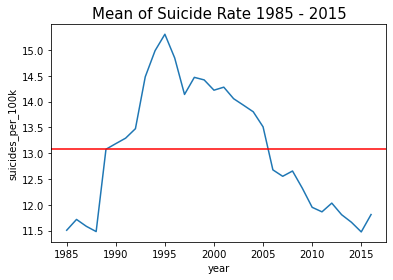

<Figure size 1008x576 with 0 Axes>

In [79]:
sns.lineplot(x = 'year', y = 'suicides_per_100k', data = df_summary)
plt.axhline(y=13.079323991106973, color='r', linestyle='-', label='Average')
plt.title('Mean of Suicide Rate 1985 - 2015',fontsize=15)
plt.figure(figsize=(14, 8))
plt.show()



KeyError: 'year'

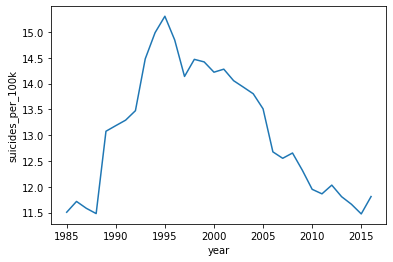

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the time series
sns.lineplot(x = 'year', y = 'suicides_per_100k', data = df_summary)

# Convert the year column to a numerical data type
df_summary[year] = pd.to_numeric(df_summary['year'])

# Set the x-axis tick marks to show every year
plt.xticks(df_summary['year'], fontsize=8)

# Add a horizontal line for the average value
plt.axhline(y=13.079323991106973, color='r', linestyle='-', label='Average')

# Add a title to the plot
plt.title('Mean of Suicide Rate 1985 - 2016', fontsize=15)

# Show the plot
plt.show()

In [53]:
df_summary['suicides_per_100k']

year
1985    11.507336
1986    11.716562
1987    11.583430
1988    11.481514
1989    13.075653
1990    13.184123
1991    13.290036
1992    13.473570
1993    14.477430
1994    14.983896
1995    15.302228
1996    14.842676
1997    14.136594
1998    14.467522
1999    14.418167
2000    14.218988
2001    14.277565
2002    14.054529
2003    13.929010
2004    13.800972
2005    13.509349
2006    12.676402
2007    12.551757
2008    12.654217
2009    12.320793
2010    11.951250
2011    11.863573
2012    12.032546
2013    11.808461
2014    11.661994
2015    11.474887
2016    11.811337
Name: suicides_per_100k, dtype: float64

In [71]:
global_average = df_summary["suicides_per_100k"].mean()
global_average

13.079323991106973

In [72]:
df_new= df_summary['suicides_per_100k']
df_new= df_new.reset_index()
df_new

,year,suicides_per_100k
0,1985,11.507336
1,1986,11.716562
2,1987,11.583430
3,1988,11.481514
4,1989,13.075653
5,1990,13.184123
6,1991,13.290036
7,1992,13.473570
8,1993,14.477430
9,1994,14.983896


In [61]:
df_new.set_index('year', inplace=True)

In [62]:
df_new

,suicides_per_100k
year,
1985,11.507336
1986,11.716562
1987,11.583430
1988,11.481514
1989,13.075653
1990,13.184123
1991,13.290036
1992,13.473570
1993,14.477430


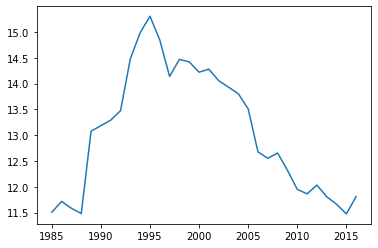

In [63]:
plt.plot(df_new)

In [64]:
import pmdarima as pm
auto_arima1 = pm.auto_arima(df_new , stepwise=True, seasonal=True)
auto_arima1

/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:1899: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:1906: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:1899: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:1906: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:1906: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.po

ARIMA(order=(1, 0, 0), scoring_args={}, suppress_warnings=True)

In [65]:
from pmdarima import auto_arima
stepwise_fit = auto_arima(df_new["suicides_per_100k"],trace=True,
                          surppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=50.516, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=106.259, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=46.402, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=76.747, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=257.625, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=46.602, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=46.579, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=48.571, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.382 seconds


/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:1899: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:1906: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:1899: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:1906: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:1906: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.po

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   32
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -20.201
Date:                Sat, 07 Jan 2023   AIC                             46.402
Time:                        00:42:23   BIC                             50.799
Sample:                             0   HQIC                            47.860
                                 - 32                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.8352      0.995      0.839      0.401      -1.115       2.785
ar.L1          0.9327      0.075     12.422      0.000       0.786       1.080
sigma2         0.1942      0.044      4.382      0.000       0.107       0.281
===================================================================================
Ljung-Box (L1) (Q):                   1.61   Jarque-Bera (JB):                20.65
Prob(Q):                              0.20   Prob(JB):                         0.00
Heteroskedasticity (H):               0.25   Skew:                             1.39
Prob(H) (two-sided):                  0.03   Kurtosis:                         5.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [67]:
from statsmodels.tsa.arima.model import ARIMA

model12 = ARIMA(df_new["suicides_per_100k"],order = (3,1,0))
model12=model12.fit()
df_new.tail()

/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,suicides_per_100k
year,
2012,12.032546
2013,11.808461
2014,11.661994
2015,11.474887
2016,11.811337


In [68]:
pred1=model12.predict(start=len(df_new), end=len(df_new)+8, typ='levels').rename('ARIMA Predeictions')
print(pred1)

32    11.883224
33    11.846556
34    11.874846
35    11.893341
36    11.890360
37    11.891693
38    11.894583
39    11.894730
40    11.894683
Name: ARIMA Predeictions, dtype: float64


/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Text(0, 0.5, 'House Price')

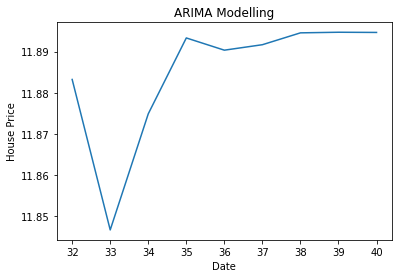

In [69]:
pred1.plot()

plt.title("ARIMA Modelling")
plt.xlabel("Date")
plt.ylabel('House Price')

In [73]:
from sklearn.linear_model import LinearRegression

# Training data
X1 = df_new.loc[:, ['year']]  # features
y1 = df_new.loc[:, 'suicides_per_100k']  # target

# Train the model
modelLR = LinearRegression()
modelLR.fit(X1, y1)

# Store the fitted values as a time series with the same time index as
# the training data
y_predr = pd.Series(modelLR.predict(X1), index=X1.index)

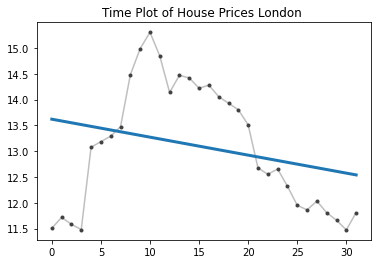

In [74]:
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)

ax = y1.plot(**plot_params)
ax = y_predr.plot(ax=ax, linewidth=3)
ax.set_title('Time Plot of House Prices London ');

In [75]:
from sklearn.metrics import r2_score
r2_score(y_predr, y1)

-11.83686091238632

                            OLS Regression Results                            
Dep. Variable:                   year   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     2.337
Date:                Sat, 07 Jan 2023   Prob (F-statistic):              0.137
Time:                        00:54:14   Log-Likelihood:                -115.34
No. Observations:                  32   AIC:                             234.7
Df Residuals:                      30   BIC:                             237.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          2027.6478     17.83

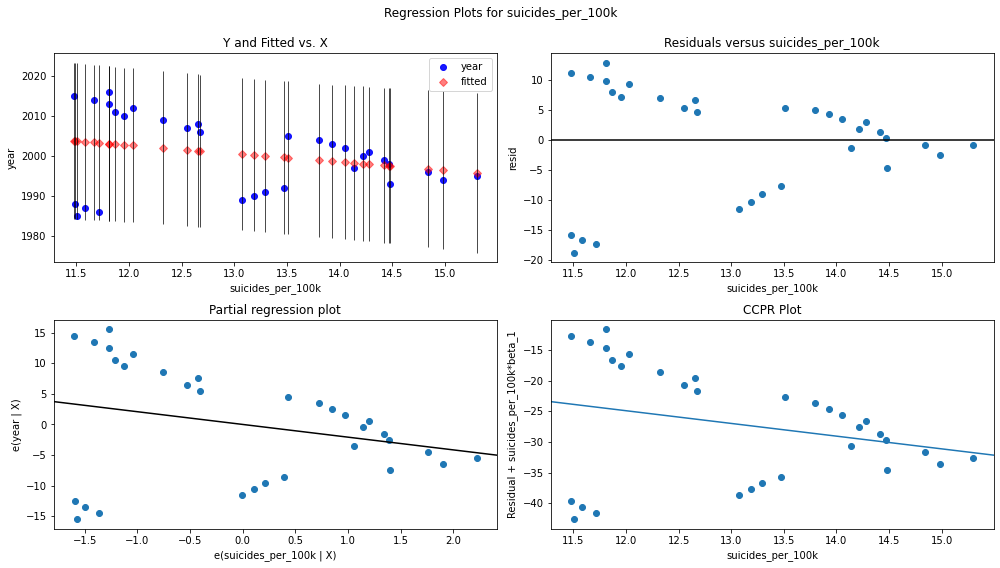

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

linear_model = ols('year ~ suicides_per_100k',
                   data=df_new).fit()
print(linear_model.summary())

# modify figure size
fig = plt.figure(figsize=(14, 8))
  
# creating regression plots
fig = sm.graphics.plot_regress_exog(linear_model,
                                    'suicides_per_100k',
                                    fig=fig)

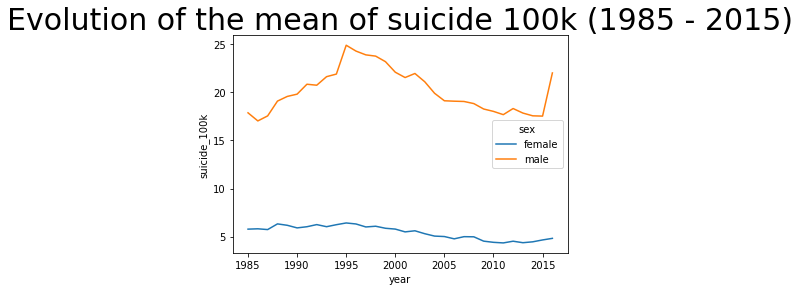

In [310]:
df1 = df.groupby(["year", "sex"]).agg("mean").reset_index()
sns.lineplot(x = "year", y = "suicide_100k", hue = "sex", data = df1)

plt.title("Evolution of the mean of suicide 100k (1985 - 2015)", size = 30);

In [164]:
def plot_scatter_links(x:str, y:str, years:list, 
                       agg_fun = "sum", n_col = None):
    
    df2 = df[df["year"].isin(years)]
    
    df2 = df.groupby(["year", "country"]).agg(agg_fun).reset_index()
    sns.lmplot(x, y, scatter = True, fit_reg= True, 
               data = df2, col = "year", col_wrap = n_col, sharex = False, sharey = False)

/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/seaborn/regression.py:592: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/seaborn/regression.py:592: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


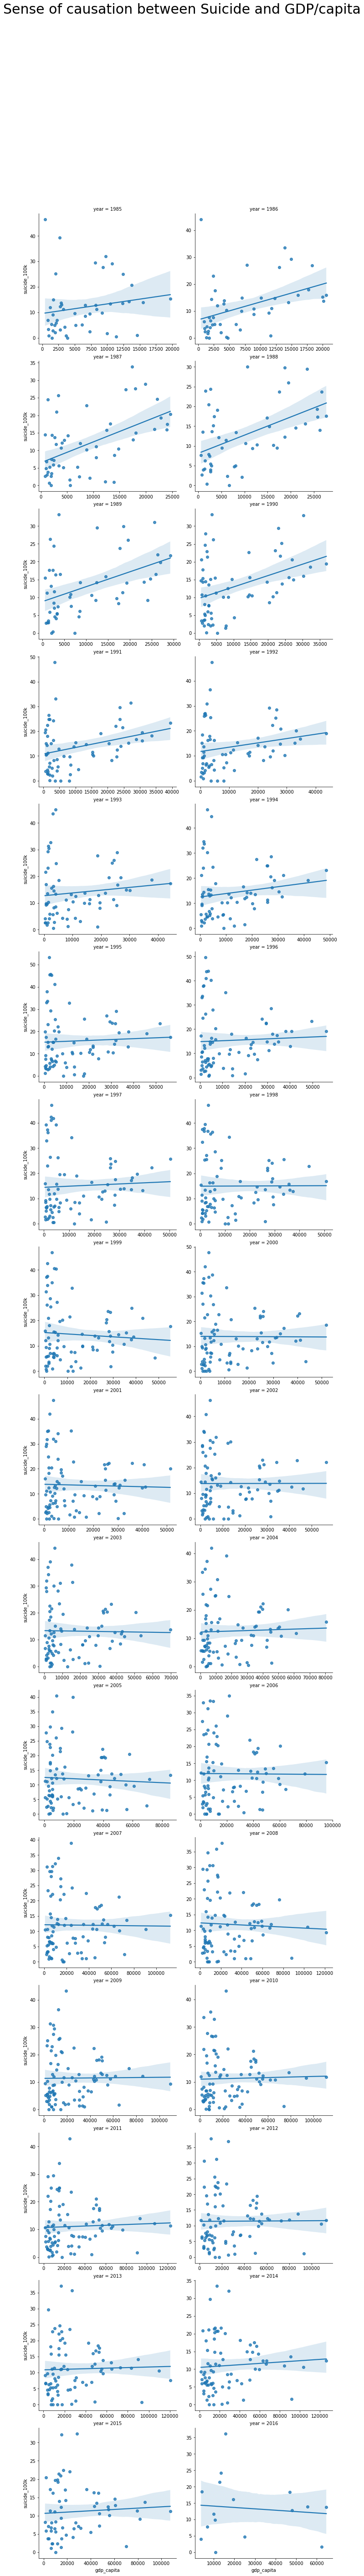

In [211]:
plot_scatter_links(x = "gdp_capita", y = "suicide_100k", 
                   years = ["1985","1995", "2005", "2015"], n_col= 2, agg_fun= "mean")
plt.subplots_adjust(top=.9)
plt.suptitle("Sense of causation between Suicide and GDP/capita", size = 30);

/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/seaborn/regression.py:592: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/mihir/opt/anaconda3/lib/python3.9/site-packages/seaborn/regression.py:592: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


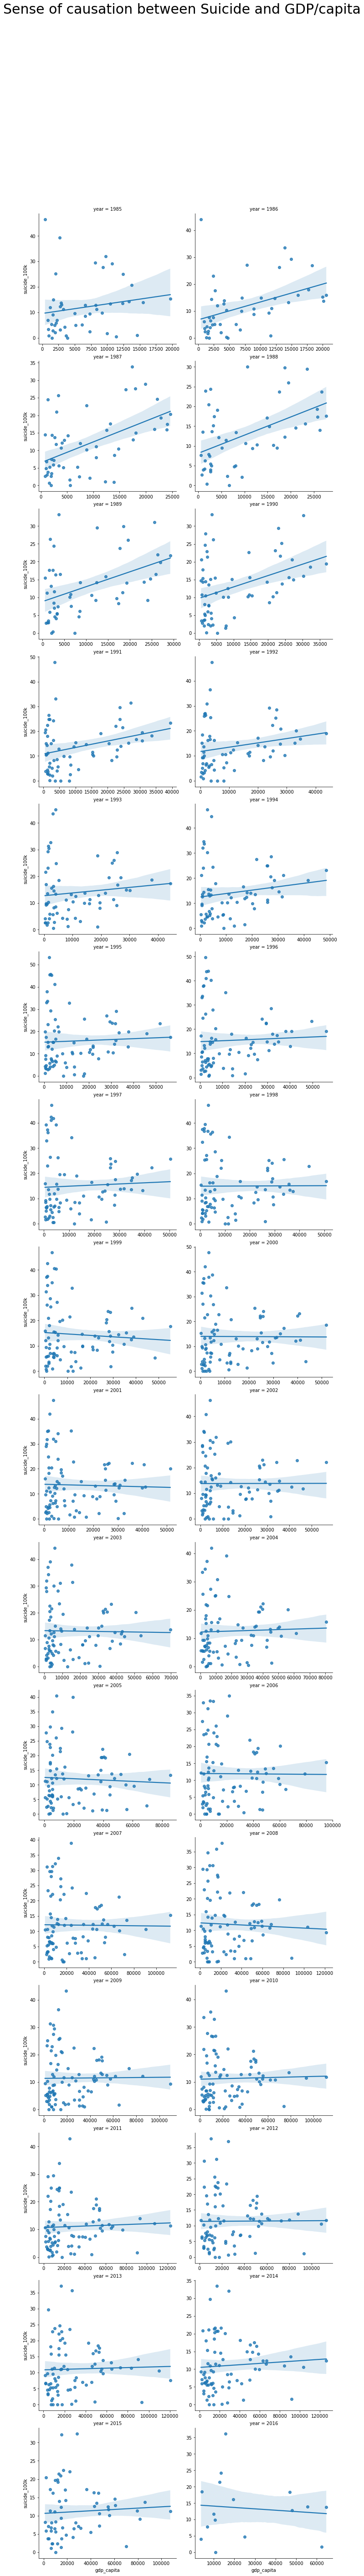

In [212]:
plot_scatter_links(x = "gdp_capita", y = "suicide_100k", 
                   years = ["1985","1995", "2005", "2015"], n_col= 2, agg_fun= "mean")
plt.subplots_adjust(top=.9)
plt.suptitle("Sense of causation between Suicide and GDP/capita", size = 30);

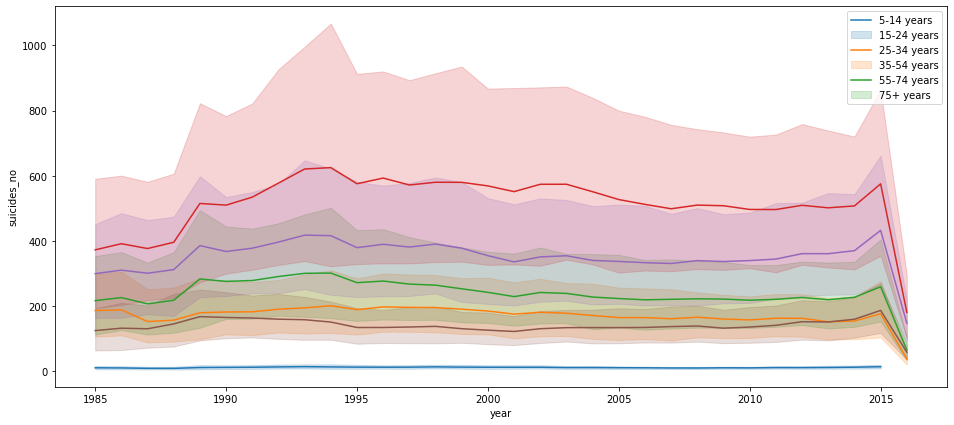

In [168]:
###we store a range of age group in variables so we can do easily lineplot
age_5 = df.loc[df.loc[:, 'age']=='5-14 years',:]
age_15 = df.loc[df.loc[:, 'age']=='15-24 years',:]
age_25 = df.loc[df.loc[:, 'age']=='25-34 years',:]
age_35 = df.loc[df.loc[:, 'age']=='35-54 years',:]
age_55 = df.loc[df.loc[:, 'age']=='55-74 years',:]
age_75 = df.loc[df.loc[:, 'age']=='75+ years',:]

### Set figure size
plt.figure(figsize=(16,7))
####Now lets plot a line plot
age_5_lp = sns.lineplot(x='year', y='suicides_no', data=age_5)
age_15_lp = sns.lineplot(x='year', y='suicides_no', data=age_15)
age_25_lp = sns.lineplot(x='year', y='suicides_no', data=age_25)
age_35_lp = sns.lineplot(x='year', y='suicides_no', data=age_35)
age_55_lp = sns.lineplot(x='year', y='suicides_no', data=age_55)
age_75_lp = sns.lineplot(x='year', y='suicides_no', data=age_75)

##Now make the legend
leg = plt.legend(['5-14 years', '15-24 years', '25-34 years', '35-54 years', '55-74 years', '75+ years'])

In [213]:
df

,country,year,sex,age,suicides_no,population,suicide_100k,country_year,hdi_for_year,current_gdp,gdp_capita,generation,occurence,part_generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,2.156625e+09,796,Generation X,1,0
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,2.156625e+09,796,Silent,1,0
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,2.156625e+09,796,Generation X,1,0
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,2.156625e+09,796,G.I. Generation,1,0
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,2.156625e+09,796,Boomers,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27815,Uzbekistan,2014,female,35-54 years,107,3620833,2.96,Uzbekistan2014,0.675,6.306708e+10,2309,Generation X,1,0
27816,Uzbekistan,2014,female,75+ years,9,348465,2.58,Uzbekistan2014,0.675,6.306708e+10,2309,Silent,1,0
27817,Uzbekistan,2014,male,5-14 years,60,2762158,2.17,Uzbekistan2014,0.675,6.306708e+10,2309,Generation Z,1,0
27818,Uzbekistan,2014,female,5-14 years,44,2631600,1.67,Uzbekistan2014,0.675,6.306708e+10,2309,Generation Z,1,0


In [219]:
interm = df.pivot(columns = "generation", values = "population")
df_new = pd.concat([df, interm], axis = 1).fillna(0)
df_new = df_new.groupby(["year", "country"]).agg("sum").reset_index()

In [220]:
df_new["current_gdp"] = df_new["current_gdp"] / df_new["occurence"]
df_new["gdp_capita"] = df_new["gdp_capita"] / df_new["occurence"]
df_new["hdi_for_year"] = df_new["hdi_for_year"] / df_new["occurence"]
del df_new["occurence"]
del df_new["population"]

In [221]:
df_new

,year,country,suicides_no,suicide_100k,hdi_for_year,current_gdp,gdp_capita,part_generation,Boomers,G.I. Generation,Generation X,Generation Z,Millenials,Silent
0,1985,Antigua and Barbuda,0,0.00,0.000,2.409239e+08,3850.0,0,12538.0,7874.0,30019.0,0.0,0.0,12143.0
1,1985,Argentina,1988,134.47,0.694,8.841667e+10,3264.0,0,4419400.0,5201000.0,10768800.0,0.0,0.0,6701600.0
2,1985,Australia,1861,163.41,0.000,1.801910e+11,12374.0,0,2575000.0,3066200.0,5181800.0,0.0,0.0,3739500.0
3,1985,Austria,2091,384.81,0.764,6.938677e+10,9759.0,0,1093548.0,1922989.0,2216253.0,0.0,0.0,1877325.0
4,1985,Bahamas,1,4.76,0.000,2.320700e+09,11393.0,0,38600.0,24800.0,96800.0,0.0,0.0,43500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2316,2016,Netherlands,1886,127.39,0.000,7.772275e+11,48108.0,0,4042017.0,0.0,4676470.0,0.0,4198439.0,1322628.0
2317,2016,Qatar,68,16.43,0.000,1.524519e+11,62484.0,0,125448.0,0.0,855121.0,0.0,1223209.0,9343.0
2318,2016,Romania,1953,116.33,0.000,1.878059e+11,10020.0,0,4531656.0,0.0,5768775.0,0.0,4766768.0,1577706.0
2319,2016,Sweden,1130,138.84,0.000,5.144600e+11,55594.0,0,2227349.0,0.0,2557572.0,0.0,2488109.0,852822.0


In [222]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler()
X = X.fit_transform(df_new.drop(["year", "country"], axis = 1))

In [224]:
selected_columns = ['suicides_no', 'suicide_100k', 'hdi_for_year',
       'current_gdp', 'gdp_capita', 'part_generation', 'Boomers',
       'G.I. Generation', 'Generation X', 'Generation Z', 'Millenials',
       'Silent']

df_new[selected_columns] = X

In [227]:
df_new

,year,country,suicides_no,suicide_100k,hdi_for_year,current_gdp,gdp_capita,part_generation,Boomers,G.I. Generation,Generation X,Generation Z,Millenials,Silent
0,1985,Antigua and Barbuda,-0.410885,-1.313957,-0.648461,-0.306332,-0.689515,0.0,-0.479708,-0.242733,-0.501340,-0.260075,-0.445257,-0.466643
1,1985,Argentina,-0.129948,-0.163769,1.281230,-0.245639,-0.720533,0.0,-0.111383,1.145227,0.431010,-0.260075,-0.445257,0.321552
2,1985,Australia,-0.147895,0.083769,-0.648461,-0.182468,-0.238327,0.0,-0.265537,0.574662,-0.054058,-0.260075,-0.445257,-0.027462
3,1985,Austria,-0.115392,1.977512,1.475867,-0.258737,-0.376743,0.0,-0.389357,0.269117,-0.311530,-0.260075,-0.445257,-0.246875
4,1985,Bahamas,-0.410744,-1.273243,-0.648461,-0.304901,-0.290253,0.0,-0.477529,-0.238209,-0.495542,-0.260075,-0.445257,-0.462948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2316,2016,Netherlands,-0.144362,-0.224328,-0.648461,0.228490,1.653123,0.0,-0.142924,-0.244837,-0.097931,-0.260075,-0.037833,-0.312233
2317,2016,Qatar,-0.401276,-1.173423,-0.648461,-0.201561,2.414065,0.0,-0.470271,-0.244837,-0.429704,-0.260075,-0.326554,-0.466973
2318,2016,Romania,-0.134894,-0.318930,-0.648461,-0.177226,-0.362928,0.0,-0.102000,-0.244837,-0.003097,-0.260075,0.017318,-0.282178
2319,2016,Sweden,-0.251197,-0.126390,-0.648461,0.047619,2.049367,0.0,-0.294594,-0.244837,-0.281896,-0.260075,-0.203807,-0.367589


In [217]:
#scaling data
scaling=StandardScaler()
scaled=scaling.fit_transform(df)

scaled_df=pd.DataFrame(scaled,columns=df.columns)

ValueError: could not convert string to float: 'Albania'

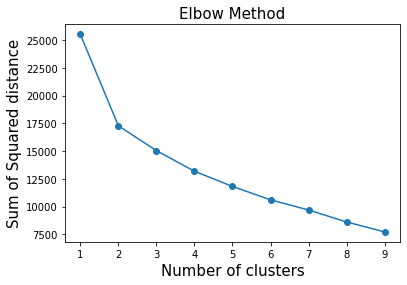

In [230]:
a=[]
K=range(1,10)
for i in K:
    kmean=KMeans(n_clusters=i)
    kmean.fit(X)
    a.append(kmean.inertia_)
    
plt.plot(K,a,marker='o')
plt.title('Elbow Method',fontsize=15)
plt.xlabel('Number of clusters',fontsize=15)
plt.ylabel('Sum of Squared distance',fontsize=15)
plt.show()

In [236]:
df_new

,year,country,suicides_no,suicide_100k,hdi_for_year,current_gdp,gdp_capita,part_generation,Boomers,G.I. Generation,Generation X,Generation Z,Millenials,Silent
0,1985,Antigua and Barbuda,-0.410885,-1.313957,-0.648461,-0.306332,-0.689515,0.0,-0.479708,-0.242733,-0.501340,-0.260075,-0.445257,-0.466643
1,1985,Argentina,-0.129948,-0.163769,1.281230,-0.245639,-0.720533,0.0,-0.111383,1.145227,0.431010,-0.260075,-0.445257,0.321552
2,1985,Australia,-0.147895,0.083769,-0.648461,-0.182468,-0.238327,0.0,-0.265537,0.574662,-0.054058,-0.260075,-0.445257,-0.027462
3,1985,Austria,-0.115392,1.977512,1.475867,-0.258737,-0.376743,0.0,-0.389357,0.269117,-0.311530,-0.260075,-0.445257,-0.246875
4,1985,Bahamas,-0.410744,-1.273243,-0.648461,-0.304901,-0.290253,0.0,-0.477529,-0.238209,-0.495542,-0.260075,-0.445257,-0.462948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2316,2016,Netherlands,-0.144362,-0.224328,-0.648461,0.228490,1.653123,0.0,-0.142924,-0.244837,-0.097931,-0.260075,-0.037833,-0.312233
2317,2016,Qatar,-0.401276,-1.173423,-0.648461,-0.201561,2.414065,0.0,-0.470271,-0.244837,-0.429704,-0.260075,-0.326554,-0.466973
2318,2016,Romania,-0.134894,-0.318930,-0.648461,-0.177226,-0.362928,0.0,-0.102000,-0.244837,-0.003097,-0.260075,0.017318,-0.282178
2319,2016,Sweden,-0.251197,-0.126390,-0.648461,0.047619,2.049367,0.0,-0.294594,-0.244837,-0.281896,-0.260075,-0.203807,-0.367589


In [237]:
data = df_new.drop(["year", "suicides_no"], axis = 1).set_index("country")

In [238]:
model = KMeans(init= "k-means++", n_clusters= 4, n_init = 20)
model = model.fit(data)

In [239]:
pd.value_counts(model.labels_, sort = False)

1    1406
3     609
2     275
0      31
dtype: int64

In [240]:
k = 4
clusters = []
for j in range(0,k):
    clusters.append([])
for i in range(0,data.shape[0]):
    clusters[model.labels_[i]].append(data.index[i])
#
# Print out clusters
#
for j in range(0,k):
    print(30*"-", "\n")
    print( j, clusters[j])


------------------------------ 

0 ['United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States']
------------------------------ 

1 ['Antigua and Barbuda', 'Australia', 'Bahamas', 'Dominica', 'Grenada', 'Puerto Rico', 'Republic of Korea', 'Saint Vincent and Grenadines', 'Seychelles', 'Singapore', 'Suriname', 'Antigua and Barbuda', 'Argentina', 'Australia', 'Austria', 'Barbados', 'Belgium', 'Belize', 'Bulgaria', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Ecuador', 'Greece', 'Guatemala', 'Iceland', 'Ireland', 'Israel', 'Jamaica

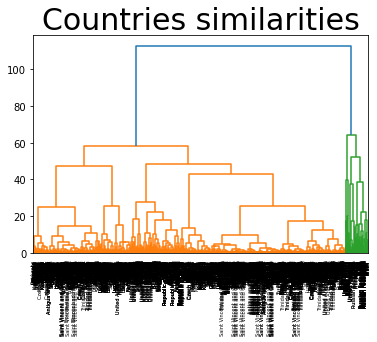

In [243]:
from scipy.cluster import hierarchy as sch

z = sch.linkage(data, method = "ward")

info = sch.dendrogram(z, orientation = "top", labels= data.index)
plt.title("Countries similarities", size = 30);

In [244]:
data1 = df_new[df_new["year"] == "2015"].drop(["year", "suicides_no"], 
                                                       axis = 1).set_index("country")
model1 = KMeans(init= "k-means++", n_clusters= 4, n_init = 20)
model1 = model.fit(data1)

ValueError: Found array with 0 sample(s) (shape=(0, 11)) while a minimum of 1 is required.

In [279]:
a = df_new.set_index("country")
a

,year,suicides_no,suicide_100k,hdi_for_year,current_gdp,gdp_capita,part_generation,Boomers,G.I. Generation,Generation X,Generation Z,Millenials,Silent
country,,,,,,,,,,,,,
Antigua and Barbuda,1985,-0.410885,-1.313957,-0.648461,-0.306332,-0.689515,0.0,-0.479708,-0.242733,-0.501340,-0.260075,-0.445257,-0.466643
Argentina,1985,-0.129948,-0.163769,1.281230,-0.245639,-0.720533,0.0,-0.111383,1.145227,0.431010,-0.260075,-0.445257,0.321552
Australia,1985,-0.147895,0.083769,-0.648461,-0.182468,-0.238327,0.0,-0.265537,0.574662,-0.054058,-0.260075,-0.445257,-0.027462
Austria,1985,-0.115392,1.977512,1.475867,-0.258737,-0.376743,0.0,-0.389357,0.269117,-0.311530,-0.260075,-0.445257,-0.246875
Bahamas,1985,-0.410744,-1.273243,-0.648461,-0.304901,-0.290253,0.0,-0.477529,-0.238209,-0.495542,-0.260075,-0.445257,-0.462948
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Netherlands,2016,-0.144362,-0.224328,-0.648461,0.228490,1.653123,0.0,-0.142924,-0.244837,-0.097931,-0.260075,-0.037833,-0.312233
Qatar,2016,-0.401276,-1.173423,-0.648461,-0.201561,2.414065,0.0,-0.470271,-0.244837,-0.429704,-0.260075,-0.326554,-0.466973
Romania,2016,-0.134894,-0.318930,-0.648461,-0.177226,-0.362928,0.0,-0.102000,-0.244837,-0.003097,-0.260075,0.017318,-0.282178


In [280]:
print(a.columns)

Index(['year', 'suicides_no', 'suicide_100k', 'hdi_for_year', 'current_gdp',
       'gdp_capita', 'part_generation', 'Boomers', 'G.I. Generation',
       'Generation X', 'Generation Z', 'Millenials', 'Silent'],
      dtype='object')


In [281]:
a["year"] == "1985"

country
Antigua and Barbuda    False
Argentina              False
Australia              False
Austria                False
Bahamas                False
                       ...  
Netherlands            False
Qatar                  False
Romania                False
Sweden                 False
Thailand               False
Name: year, Length: 2321, dtype: bool

In [305]:
print(df['year'].dtype)

int64


In [308]:
f = df_new[df_new["year"] == "2015"].drop(["year", "suicides_no"], 
                                                       axis = 1).set_index("country")

In [309]:
f

,suicide_100k,hdi_for_year,current_gdp,gdp_capita,part_generation,Boomers,G.I. Generation,Generation X,Generation Z,Millenials,Silent
country,,,,,,,,,,,


In [307]:
filtered_df = a[a['year'].isin([1985])]
filtered_df

,year,suicides_no,suicide_100k,hdi_for_year,current_gdp,gdp_capita,part_generation,Boomers,G.I. Generation,Generation X,Generation Z,Millenials,Silent
country,,,,,,,,,,,,,


In [287]:
import datetime as dt


q = a[a["year"] == "2000"].drop(["year", "suicides_no"], axis = 1)

In [289]:
a

,year,suicides_no,suicide_100k,hdi_for_year,current_gdp,gdp_capita,part_generation,Boomers,G.I. Generation,Generation X,Generation Z,Millenials,Silent
country,,,,,,,,,,,,,
Antigua and Barbuda,1985,-0.410885,-1.313957,-0.648461,-0.306332,-0.689515,0.0,-0.479708,-0.242733,-0.501340,-0.260075,-0.445257,-0.466643
Argentina,1985,-0.129948,-0.163769,1.281230,-0.245639,-0.720533,0.0,-0.111383,1.145227,0.431010,-0.260075,-0.445257,0.321552
Australia,1985,-0.147895,0.083769,-0.648461,-0.182468,-0.238327,0.0,-0.265537,0.574662,-0.054058,-0.260075,-0.445257,-0.027462
Austria,1985,-0.115392,1.977512,1.475867,-0.258737,-0.376743,0.0,-0.389357,0.269117,-0.311530,-0.260075,-0.445257,-0.246875
Bahamas,1985,-0.410744,-1.273243,-0.648461,-0.304901,-0.290253,0.0,-0.477529,-0.238209,-0.495542,-0.260075,-0.445257,-0.462948
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Netherlands,2016,-0.144362,-0.224328,-0.648461,0.228490,1.653123,0.0,-0.142924,-0.244837,-0.097931,-0.260075,-0.037833,-0.312233
Qatar,2016,-0.401276,-1.173423,-0.648461,-0.201561,2.414065,0.0,-0.470271,-0.244837,-0.429704,-0.260075,-0.326554,-0.466973
Romania,2016,-0.134894,-0.318930,-0.648461,-0.177226,-0.362928,0.0,-0.102000,-0.244837,-0.003097,-0.260075,0.017318,-0.282178


In [299]:
a.type

AttributeError: 'DataFrame' object has no attribute 'type'

In [300]:
import datetime as dt
a

,year,suicides_no,suicide_100k,hdi_for_year,current_gdp,gdp_capita,part_generation,Boomers,G.I. Generation,Generation X,Generation Z,Millenials,Silent
country,,,,,,,,,,,,,
Antigua and Barbuda,1970-01-01 00:00:00.000001985,-0.410885,-1.313957,-0.648461,-0.306332,-0.689515,0.0,-0.479708,-0.242733,-0.501340,-0.260075,-0.445257,-0.466643
Argentina,1970-01-01 00:00:00.000001985,-0.129948,-0.163769,1.281230,-0.245639,-0.720533,0.0,-0.111383,1.145227,0.431010,-0.260075,-0.445257,0.321552
Australia,1970-01-01 00:00:00.000001985,-0.147895,0.083769,-0.648461,-0.182468,-0.238327,0.0,-0.265537,0.574662,-0.054058,-0.260075,-0.445257,-0.027462
Austria,1970-01-01 00:00:00.000001985,-0.115392,1.977512,1.475867,-0.258737,-0.376743,0.0,-0.389357,0.269117,-0.311530,-0.260075,-0.445257,-0.246875
Bahamas,1970-01-01 00:00:00.000001985,-0.410744,-1.273243,-0.648461,-0.304901,-0.290253,0.0,-0.477529,-0.238209,-0.495542,-0.260075,-0.445257,-0.462948
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Netherlands,1970-01-01 00:00:00.000002016,-0.144362,-0.224328,-0.648461,0.228490,1.653123,0.0,-0.142924,-0.244837,-0.097931,-0.260075,-0.037833,-0.312233
Qatar,1970-01-01 00:00:00.000002016,-0.401276,-1.173423,-0.648461,-0.201561,2.414065,0.0,-0.470271,-0.244837,-0.429704,-0.260075,-0.326554,-0.466973
Romania,1970-01-01 00:00:00.000002016,-0.134894,-0.318930,-0.648461,-0.177226,-0.362928,0.0,-0.102000,-0.244837,-0.003097,-0.260075,0.017318,-0.282178


In [296]:
a['year'] = pd.to_datetime(a['year'])

a

,year,suicides_no,suicide_100k,hdi_for_year,current_gdp,gdp_capita,part_generation,Boomers,G.I. Generation,Generation X,Generation Z,Millenials,Silent
country,,,,,,,,,,,,,
Antigua and Barbuda,1970-01-01 00:00:00.000001985,-0.410885,-1.313957,-0.648461,-0.306332,-0.689515,0.0,-0.479708,-0.242733,-0.501340,-0.260075,-0.445257,-0.466643
Argentina,1970-01-01 00:00:00.000001985,-0.129948,-0.163769,1.281230,-0.245639,-0.720533,0.0,-0.111383,1.145227,0.431010,-0.260075,-0.445257,0.321552
Australia,1970-01-01 00:00:00.000001985,-0.147895,0.083769,-0.648461,-0.182468,-0.238327,0.0,-0.265537,0.574662,-0.054058,-0.260075,-0.445257,-0.027462
Austria,1970-01-01 00:00:00.000001985,-0.115392,1.977512,1.475867,-0.258737,-0.376743,0.0,-0.389357,0.269117,-0.311530,-0.260075,-0.445257,-0.246875
Bahamas,1970-01-01 00:00:00.000001985,-0.410744,-1.273243,-0.648461,-0.304901,-0.290253,0.0,-0.477529,-0.238209,-0.495542,-0.260075,-0.445257,-0.462948
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Netherlands,1970-01-01 00:00:00.000002016,-0.144362,-0.224328,-0.648461,0.228490,1.653123,0.0,-0.142924,-0.244837,-0.097931,-0.260075,-0.037833,-0.312233
Qatar,1970-01-01 00:00:00.000002016,-0.401276,-1.173423,-0.648461,-0.201561,2.414065,0.0,-0.470271,-0.244837,-0.429704,-0.260075,-0.326554,-0.466973
Romania,1970-01-01 00:00:00.000002016,-0.134894,-0.318930,-0.648461,-0.177226,-0.362928,0.0,-0.102000,-0.244837,-0.003097,-0.260075,0.017318,-0.282178
